In [1]:
# FRA OPPGAVEN FØR, TRENGER IKKE Å KOPIERES OVER!
%matplotlib widget
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.fft import fft, ifft, fft2, ifft2, fftfreq, fftshift
import project_tools as pt
from IPython.display import HTML

def IMEX_solver(*, 
                                kappa, 
                                X, Y, U0, 
                                t0, T, Nt,
                                g, coeff,
                                alpha=1.5):
    """
    Implements the Cahn-Hilliard equation solver using the backward Euler method 
    with a convex-concave splitting approach.

    Parameters:
    -----------
    kappa : float
        Diffusion coefficient for the biharmonic operator.
    X : ndarray
        2D array representing the x-coordinates of the grid.
    Y : ndarray
        2D array representing the y-coordinates of the grid.
    U0 : ndarray
        Initial condition for the solution.
    t0 : float
        Initial time.
    T : float
        Final time.
    Nt : int
        Number of time steps.
    g : callable or None
        Source term as a function of (X, Y, t). If None, no source term is applied.
    alpha : float, optional
        Convex-concave splitting parameter. Default is 1.5.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.

    """

    # Prepare relevant data for Fourier transform
    N, M = U0.shape
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    k_x = (fftfreq(N, d=dx/(2*np.pi)))
    k_y = (fftfreq(M, d=dy/(2*np.pi)))
    alpha_10, alpha_11, alpha_20, alpha_21, alpha_22, beta_1, beta_2 = coeff

    KX, KY = np.meshgrid(k_x, k_y, indexing="ij")
    K2 = -(KX**2 + KY**2)
    K4 = K2**2

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    # Add your time-stepping loop here
    # Time stepping 
    t = t0 
    dt = (T-t0)/Nt

    # For convenience when plotting, computing errors, etc., 
    # return the initial solution and initial time.
    yield U_hat, t  

    
    while t < T-dt/2:
        # Compute source term in Fourier space if provided
        if g is not None:
            g_hat = fft2(g(X, Y, t + dt/2, kappa))
        else:
            g_hat = 0
        
        def NonLinear(U_hat):
            U = ifft2(U_hat).real
            NonLin = U**3 - (1 + alpha) * U
            return K2*fft2(NonLin)

        # Bruker Song metoden for å finne neste steglengde
        # U_hat er U^n
        U_hat_1 = (U_hat + dt * (NonLinear(U_hat) + g_hat)) / (1 + dt * (kappa * K4 - alpha * K2))
        U_hat_2 = (alpha_10 * U_hat + alpha_11 * U_hat_1 + beta_1 * dt * (NonLinear(U_hat_1) + g_hat)) / (1 + beta_1 * dt * (kappa * K4 - alpha * K2))
        U_hat = (alpha_20 * U_hat + alpha_21 * U_hat_1 + alpha_22 * U_hat_2 + beta_2 * dt * (NonLinear(U_hat_2) + g_hat)) / (1 + beta_2 * dt * (kappa * K4 - alpha * K2))
        # Oppdaterer U_hat og t
        t += dt

        yield U_hat, t

In [18]:
def cahn_hilliard_backward_euler(*, 
                                kappa, 
                                X, Y, U0, 
                                t0, T, Nt,
                                g, 
                                alpha=1.5):
    """
    Implements the Cahn-Hilliard equation solver using the backward Euler method 
    with a convex-concave splitting approach.

    Parameters:
    -----------
    kappa : float
        Diffusion coefficient for the biharmonic operator.
    X : ndarray
        2D array representing the x-coordinates of the grid.
    Y : ndarray
        2D array representing the y-coordinates of the grid.
    U0 : ndarray
        Initial condition for the solution.
    t0 : float
        Initial time.
    T : float
        Final time.
    Nt : int
        Number of time steps.
    g : callable or None
        Source term as a function of (X, Y, t). If None, no source term is applied.
    alpha : float, optional
        Convex-concave splitting parameter. Default is 1.5.

    Yields:
    -------
    tuple: A tuple containing the discrete Fourier transform of U at t, and the current time t.

    """

    # Prepare relevant data for Fourier transform
    N, M = U0.shape  # U0 is a NxM matrix, but in python .shape gives them in reverse order
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    k_x = (fftfreq(N, d=dx/(2*np.pi)))
    k_y = (fftfreq(M, d=dy/(2*np.pi)))

    KX, KY = np.meshgrid(k_x, k_y, indexing="ij")
    K2 = -(KX**2 + KY**2)
    K4 = K2**2

    # Compute DFT of the initial value
    U_hat = fft2(U0)

    # Add your time-stepping loop here
    # Time stepping 
    t = t0 
    dt = (T-t0)/Nt

    # For convenience when plotting, computing errors, etc., 
    # return the initial solution and initial time.
    yield U_hat, t  

    
    while t < T-dt/2:
        # Compute source term in Fourier space if provided
        if g is not None:
            g_hat = fft2(g(X, Y, t + dt))                           # g skal behandles implisitt, bruker t + dt
        else:
            g_hat = 0
    

        
        U_lin = (ifft2(U_hat))**3 - (1+alpha)*(ifft2(U_hat))        # Finner lineær del i det fysiske rom
        U_lin_hat = fft2(U_lin)                                     # Finner lineær del i Fourierrommet 

        denominator = 1 + dt*(kappa*K4 - alpha*K2)
        numerator = U_hat + dt*(K2*U_lin_hat + g_hat)
        U_hat = numerator/denominator

        # Update time
        t += dt

        yield U_hat, t

In [14]:
kappa = 0.0025**2
coeff = (2, -1, 0, 1/2, 1/2, 1, 1/2)

Lx, Ly = 0.5, 0.5                                   # Definerer området
Nx, Ny = 256, 256                                   # Definerer oppløsning
dA = Lx/Nx * Ly/Ny                                  # Definerer arealelement
x, y = np.linspace(0, Lx, Nx, endpoint = False), np.linspace(0, Ly, Ny, endpoint = False)     
X, Y = np.meshgrid(x, y)                            # Oppretter grid

# Definerer liste med to ulike tidsintervall
t0 = 0
intervals = np.array([4.0, 0.01])                        

# Definerer liste med to ulike initialbetingelser
rng = np.random.default_rng(12345)
noise_1 = 0.05
u0_base_1 = 0.0
U0_1 = np.ones_like((Ny, Nx))
U0_1 = np.full((Ny, Nx), u0_base_1) +  noise_1*rng.standard_normal((Ny, Nx))

noise_2 = 0.05
u0_base_2 = -0.45
U0_2 = np.ones_like((Ny, Nx))
U0_2 = np.full((Ny, Nx), u0_base_2) +  noise_2*rng.standard_normal((Ny, Nx))

U0s = np.array([U0_1, U0_2])

# Definerer liste med to ulike steglengder
dts = np.array([10**(-3), 10**(-4)])                

In [3]:
# Definerer nødvendige funksjoner

def total_mass(U):
    return np.sum(U)*dA


def F(u):                               # Definerer funksjon for Helmholtz frie energitetthet F(u)
    return (1/4)*(u**2 - 1)**2

def mixing_energy(U):                   # Definerer funksjon for blandingsenergi
    return np.sum(F(U))*dA              # Evaluerer F(u) i U og summerer over hele gridet


def interface_energy(kappa, U, Nx, Ny, Lx, Ly):
    U_hat = fft2(U)

    kx = fftfreq(Nx, d=Lx/Nx)*2*np.pi
    ky = fftfreq(Ny, d=Ly/Ny)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    U_hat_x = 1j*KX * U_hat
    U_hat_y = 1j*KY * U_hat
    U_x = ifft2(U_hat_x).real
    U_y = ifft2(U_hat_y).real

    U_grad_squared = U_x**2 + U_y**2
    
    int_energy = np.sum((kappa/2)*U_grad_squared) * dA

    return int_energy


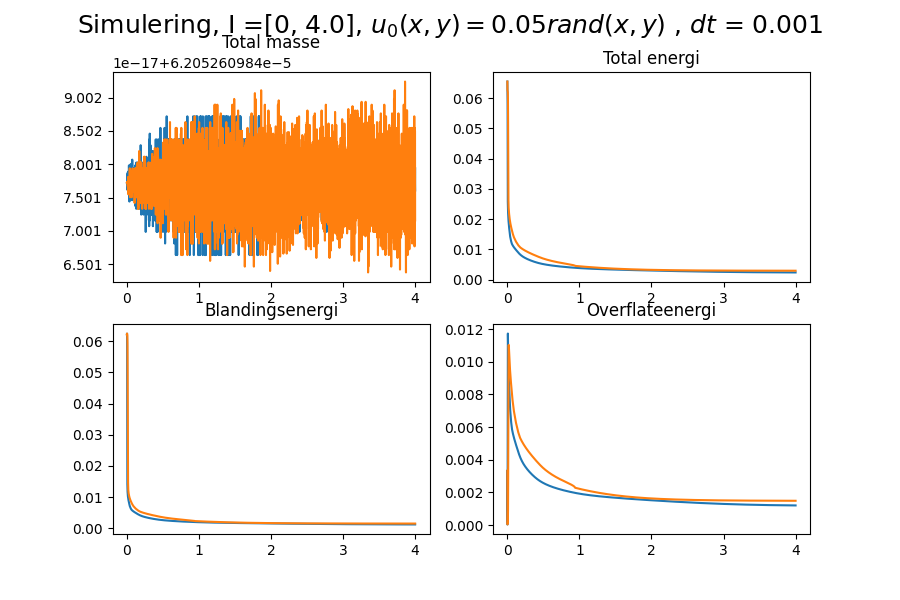

In [ ]:
solver1 =lambda T, U0, dt: IMEX_solver(kappa = kappa, X = X, Y = Y, U0 = U0, t0 = t0, T = T, Nt = T/dt, g=None, coeff=coeff)
solver2 =lambda T, U0, dt: cahn_hilliard_backward_euler(kappa = kappa, X = X, Y = Y, U0 = U0, t0 = t0, T = T, Nt = T/dt, g=None)

html_output=[]
for T in intervals:
    for U0 in U0s:
        for dt in dts:
            total_mass_list = [[], []]
            mixing_energy_list = [[], []]
            interface_energy_list = [[], []]
            times_list = [[], []]

            snapshot_times = [0, 1, 2, 3, 4, 6, 8, 12, 32, 64, 128, 256, 512, 1000, 2000, 4000]
            snapshot_times_and_Us = []
            for i, (U_hat, t) in enumerate(solver1(T, U0, dt)):
                # Regner ut og legger inn masse og energi
                U = ifft2(U_hat).real
                times_list[0].append(t)
                total_mass_list[0].append(total_mass(U))
                mixing_energy_list[0].append(mixing_energy(U))
                interface_energy_list[0].append(interface_energy(kappa, U, Nx, Ny, Lx, Ly))
                
                # Henter ut visse bilder av løsningen
                for snapshot_time in snapshot_times:
                    if i in snapshot_times:
                        snapshot_times_and_Us.append((U, t))
                        break

            for i, (U_hat, t) in enumerate(solver2(T, U0, dt)):
                # Regner ut og legger inn masse og energi
                U = ifft2(U_hat).real
                times_list[1].append(t)
                total_mass_list[1].append(total_mass(U))
                mixing_energy_list[1].append(mixing_energy(U))
                interface_energy_list[1].append(interface_energy(kappa, U, Nx, Ny, Lx, Ly))
                

            # For IMEX
            times_list1 = np.array(times_list[0])
            total_mass_list1 = np.array(total_mass_list[0])
            mixing_energy_list1 = np.array(mixing_energy_list[0])
            interface_energy_list1 = np.array(interface_energy_list[0])
            total_energy_list1 = mixing_energy_list1 + interface_energy_list1

            # For cahn hilliard backward euler
            times_list2 = np.array(times_list[1])
            total_mass_list2 = np.array(total_mass_list[1])
            mixing_energy_list2 = np.array(mixing_energy_list[1])
            interface_energy_list2 = np.array(interface_energy_list[1])
            total_energy_list2 = mixing_energy_list2 + interface_energy_list2

            # Plotter total masse, blandingsenergi, overflateenergi og total energi
            fig, axs = plt.subplots(2, 2, figsize=(9, 6))
            if np.array_equal(U0, U0s[0]):
                fig.suptitle(f'Simulering, I =[{t0}, {T}], $u_0(x, y) = 0.05 rand(x, y)$ , $dt$ = {dt}', fontsize=18)
            else:
                fig.suptitle(f'Simulering, I =[{t0}, {T}], $u_0(x, y) = -0.45 + 0.05 rand(x, y)$ , $dt$ = {dt}', fontsize=18)

            axs[0][0].plot(times_list1, total_mass_list1)
            axs[0][0].plot(times_list2, total_mass_list2)
            axs[0][0].set_title('Total masse')

            axs[1][0].plot(times_list1, mixing_energy_list1)
            axs[1][0].plot(times_list2, mixing_energy_list2)
            axs[1][0].set_title('Blandingsenergi')

            axs[1][1].plot(times_list1, interface_energy_list1)
            axs[1][1].plot(times_list2, interface_energy_list2)
            axs[1][1].set_title('Overflateenergi')

            axs[0][1].plot(times_list1, total_energy_list1)
            axs[0][1].plot(times_list2, total_energy_list2)
            axs[0][1].set_title('Total energi')

            plt.show()

            ani = pt.create_animation(snapshot_times_and_Us, Lx, Ly)
            html_output.append(HTML(ani.to_jshtml()))

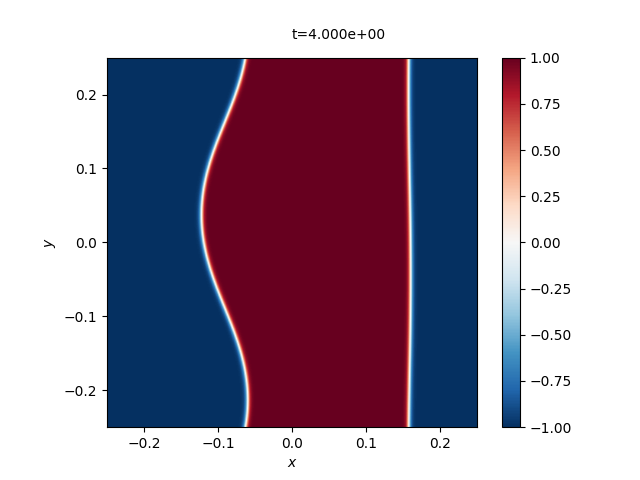

In [23]:
html_output